# Destripe Preprocessing Demo

This notebook is set up for `Run All`. Most users only need to fill in four lines: a workspace folder, an optional input image or volume, and the two destriping parameters.

If `INPUT_IMAGE_PATH` is left as `None`, the notebook runs the built-in synthetic destripe example. If you set your own input path, the notebook stages it into the workspace, converts color inputs to grayscale when possible, runs destriping, and tells you where the destriped TIFF was written.


## User Settings

Fill in the four lines in the next cell before running the notebook. Leave `INPUT_IMAGE_PATH` as `None` to use the built-in synthetic example.


In [1]:
WORKSPACE_DIR = None
INPUT_IMAGE_PATH = None
SIGMA = 8.0
MAX_THRESHOLD = 12.0


## Load Notebook Helpers

This cell imports the Python helpers used by the rest of the notebook.


In [2]:
from pathlib import Path
import sys

NOTEBOOK_ROOT = Path.cwd().resolve()
if not (NOTEBOOK_ROOT / 'deepbranchai').exists():
    for parent in NOTEBOOK_ROOT.parents:
        if (parent / 'deepbranchai').exists():
            NOTEBOOK_ROOT = parent
            break
if str(NOTEBOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(NOTEBOOK_ROOT))

from deepbranchai import (
    DestripeDemoConfig,
    ensure_destripe_filter,
    prepare_destripe_demo,
    rmse,
    row_bias_std,
    run_destripe,
    show_destripe_crop,
    show_destripe_overview,
)

DEFAULT_WORKSPACE_DIR = Path(r'F:\DeepBranchAI')


## Set Up The Managed Workspace

This block builds the managed workspace, stages your input if you provided one, or creates the built-in synthetic example if you did not.


In [3]:
WORKSPACE_DIR = Path(WORKSPACE_DIR) if WORKSPACE_DIR else (DEFAULT_WORKSPACE_DIR if DEFAULT_WORKSPACE_DIR.exists() else None)
INPUT_IMAGE_PATH = Path(INPUT_IMAGE_PATH) if INPUT_IMAGE_PATH else None

config = DestripeDemoConfig(
    storage_dir=WORKSPACE_DIR,
    sigma=float(SIGMA),
    max_threshold=float(MAX_THRESHOLD),
)
state = prepare_destripe_demo(config, input_path=INPUT_IMAGE_PATH, reset_workspace=True)
state.show()


Workspace root:   F:\DeepBranchAI
Managed input:    F:\DeepBranchAI\data\destripe_demo\input\synthetic_striped_input.tif
Output image:     F:\DeepBranchAI\data\destripe_demo\output\synthetic_destriped_output.tif
Demo mode:        True
Input shape:      (512, 512)


## Run Destriping

This block loads the destripe filter, runs one destriping pass, and writes the destriped TIFF into the managed output folder.


In [4]:
filter_fn = ensure_destripe_filter()
output_path = run_destripe(state, filter_fn=filter_fn)
print(f'Destriped output saved to: {output_path}')
if state.clean_reference is not None:
    print()
    print('Before/after vs. clean synthetic image')
    print(f'RMSE:         {rmse(state.input_array, state.clean_reference):5.2f} -> {rmse(state.filtered_array, state.clean_reference):5.2f}')
    print(f'Row bias std: {row_bias_std(state.input_array, state.clean_reference):5.2f} -> {row_bias_std(state.filtered_array, state.clean_reference):5.2f}')


Destriped output saved to: F:\DeepBranchAI\data\destripe_demo\output\synthetic_destriped_output.tif

Before/after vs. clean synthetic image
RMSE:          4.47 ->  1.91
Row bias std:  4.47 ->  1.41


## Visualize Results

These blocks show the input and destriped result. The synthetic demo also shows the clean reference.


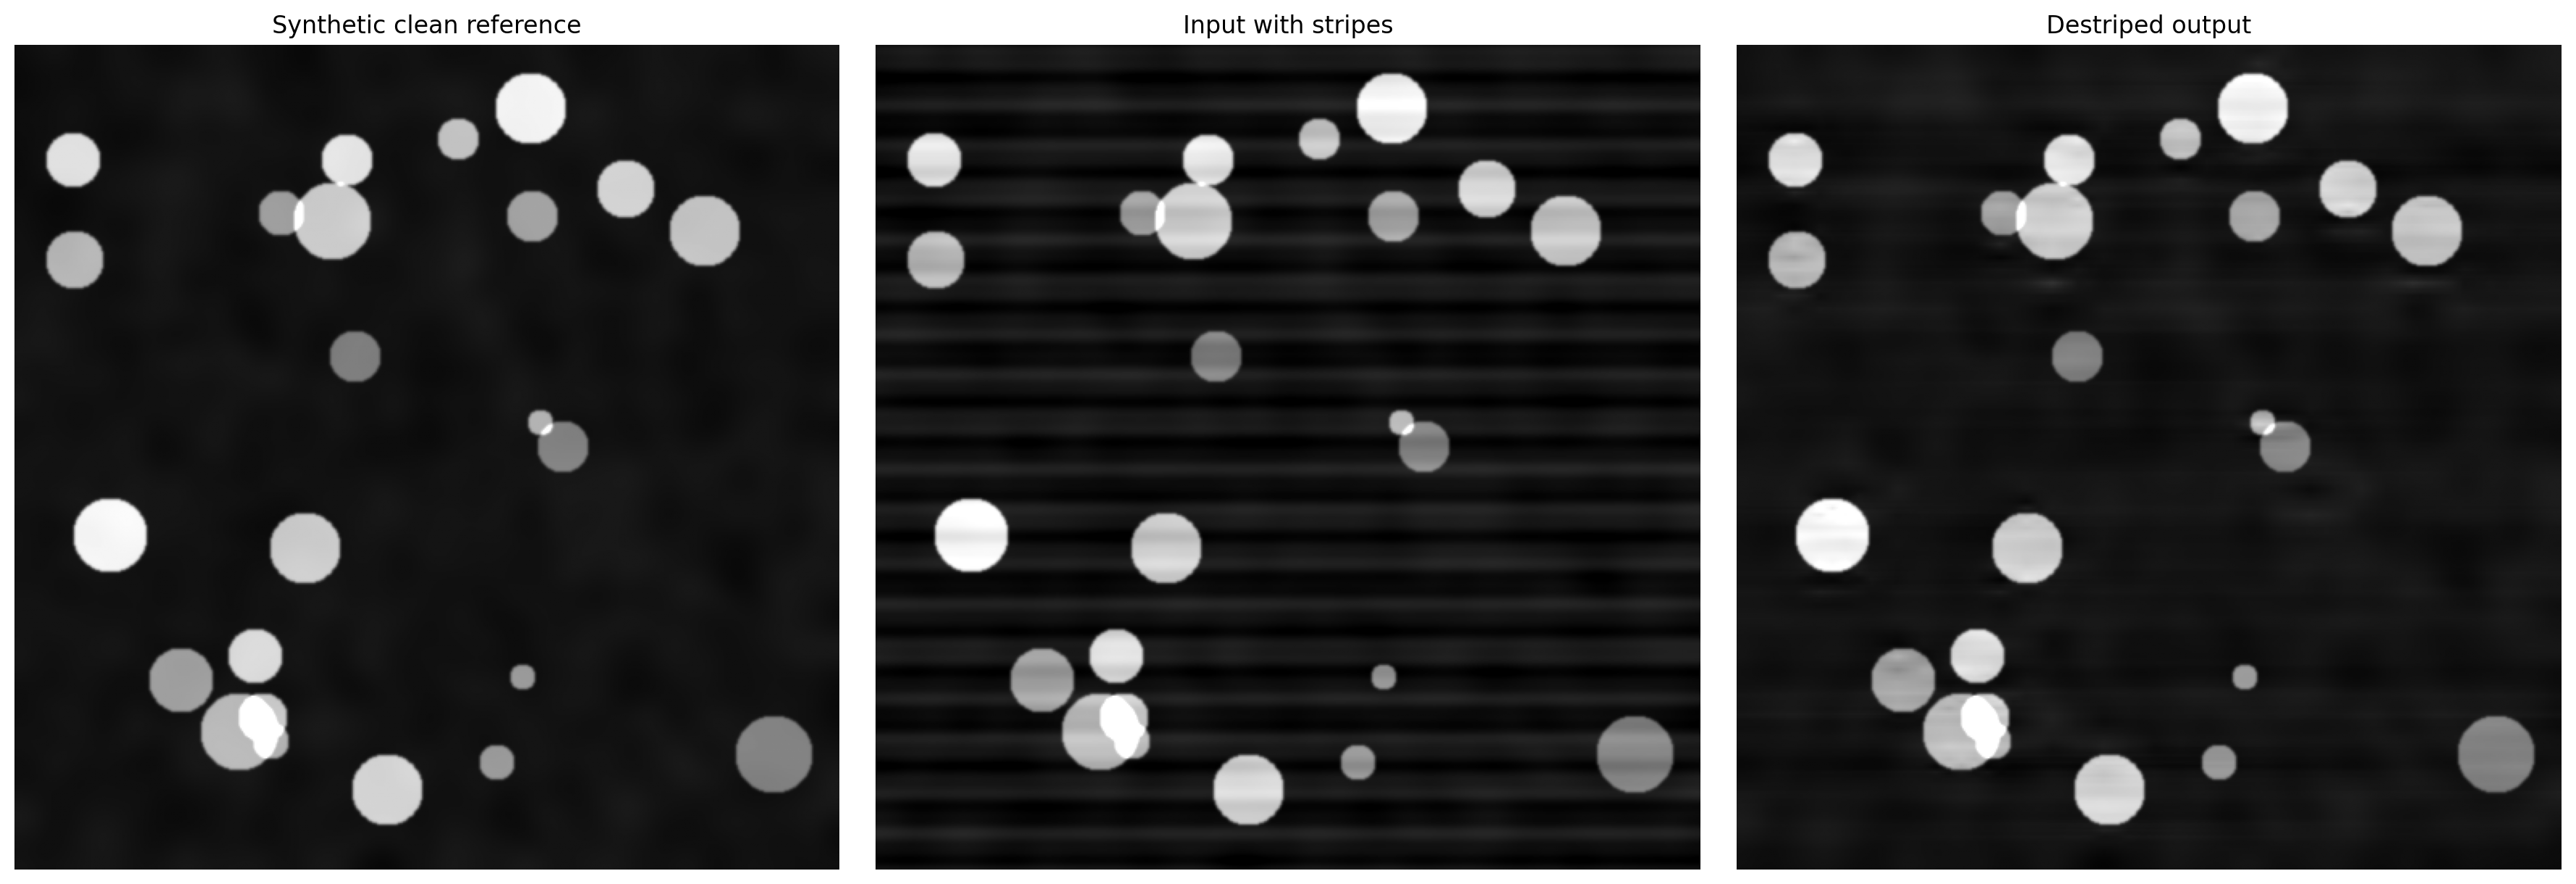

In [5]:
show_destripe_overview(state, dpi=200)


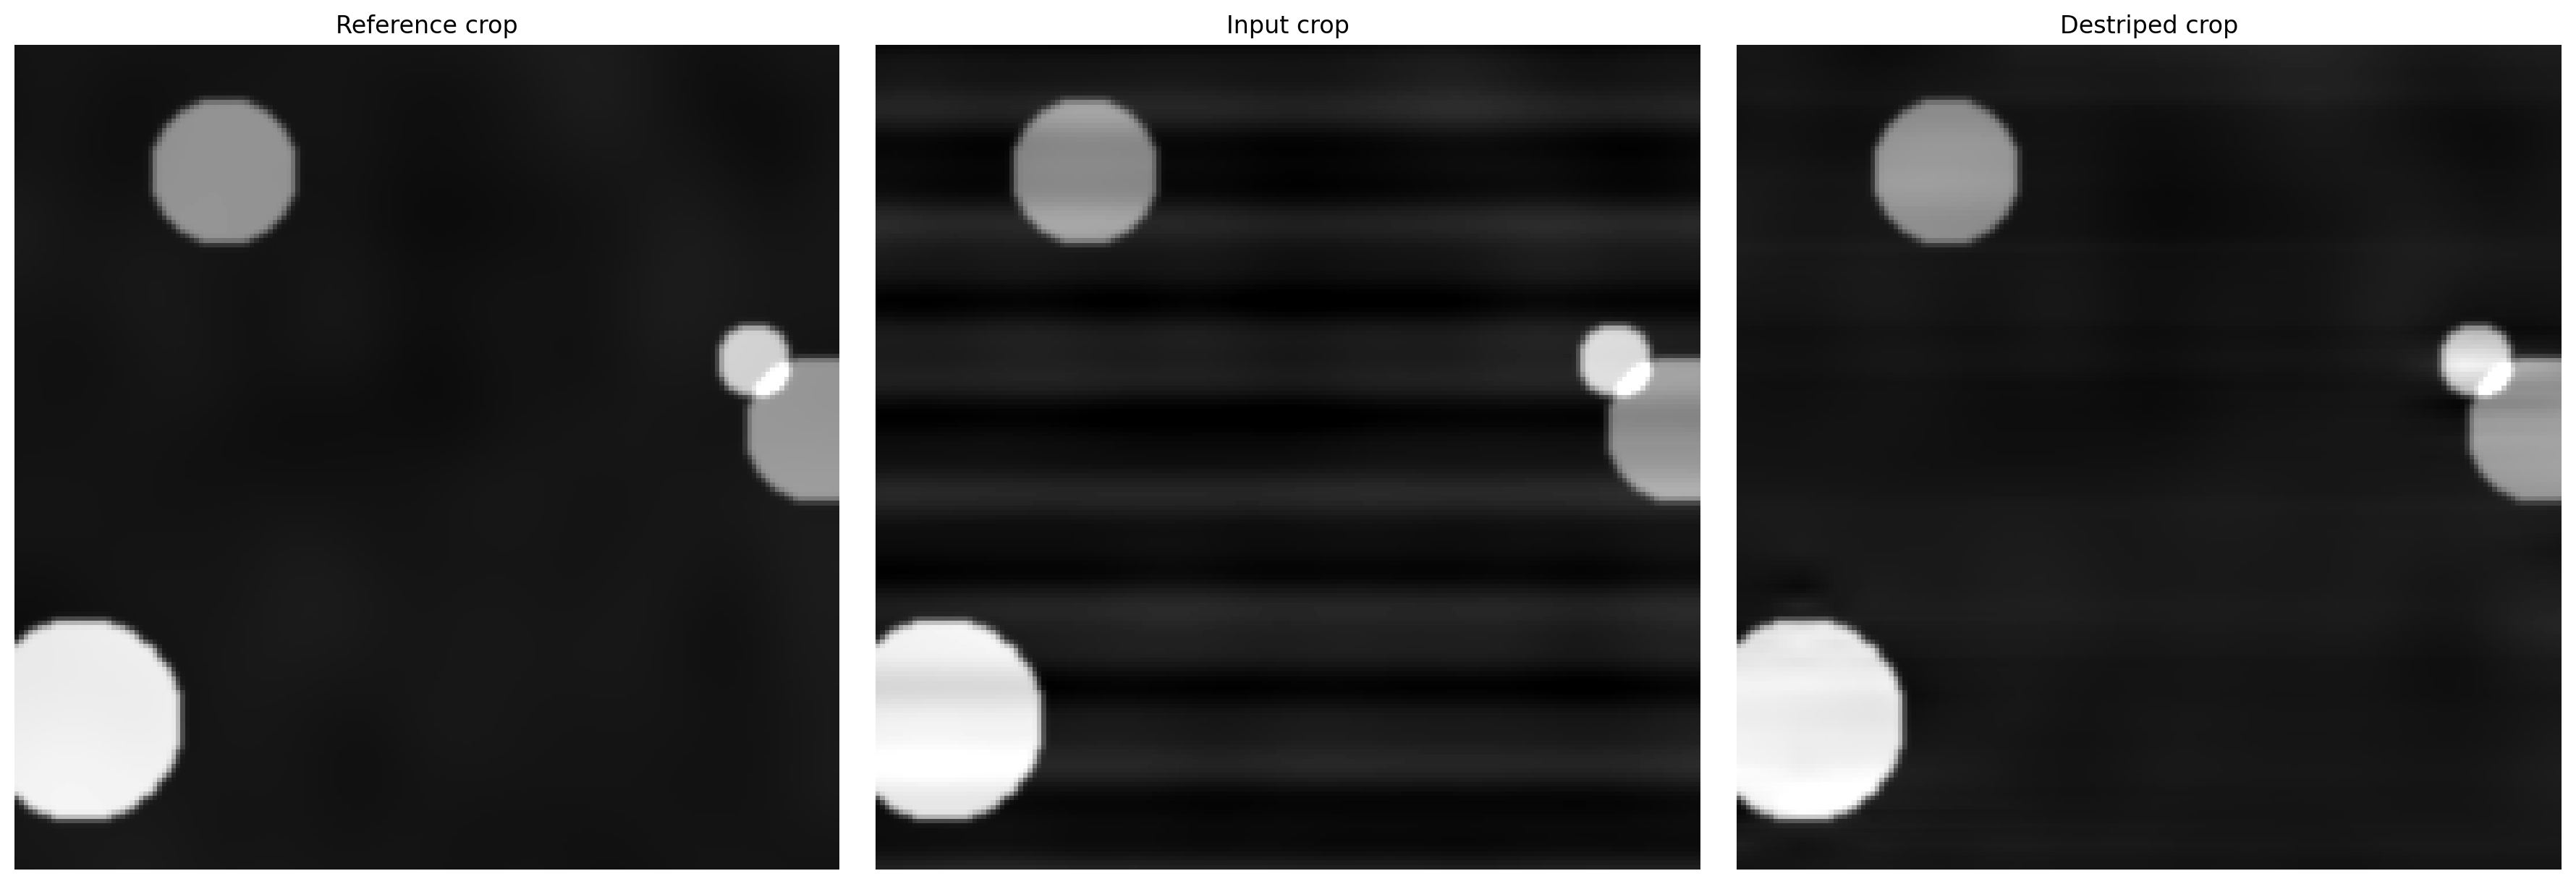

In [6]:
show_destripe_crop(state, dpi=200)


## Parameters

- `SIGMA`: higher values preserve more detail and remove stripes more conservatively
- `MAX_THRESHOLD`: lower values remove stripes more aggressively

The notebook saves the destriped TIFF to the printed output path so you do not need to inspect internal folders.
